This code has been ran on September 14 2026 using release August 6 2026 of Google Colab Pro.

In [ ]:
#!pip install -U "protobuf>=6.31.1"
!pip install -U protobuf tensorflow-metadata tensorflow-datasets

In [ ]:
!pip install -U importlib-resources

In [ ]:
import importlib_resources
import tensorflow_datasets as tfds

dataset, info = tfds.load(
    "oxford_iiit_pet:4.0.0",
    with_info=True
)

In [ ]:
# Re-import the libraries after reinstalling them to ensure the new versions are used
import tensorflow as tf
import matplotlib.pylab as plt
import numpy as np
import cv2

In [ ]:
def read_and_preprocess(data):
  input_image =     #Resize the data['image'] to 128x128
  input_mask =     #Resize the data['segmentation_mask'] to 128x128

  input_image = tf.image.convert_image_dtype(input_image, tf.float32) # [0,1]
  input_mask -= 1 # {1,2,3} to {0,1,2}

  return input_image, input_mask

In [ ]:
train = dataset['train'].map(read_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test = dataset['test'].map(read_and_preprocess)

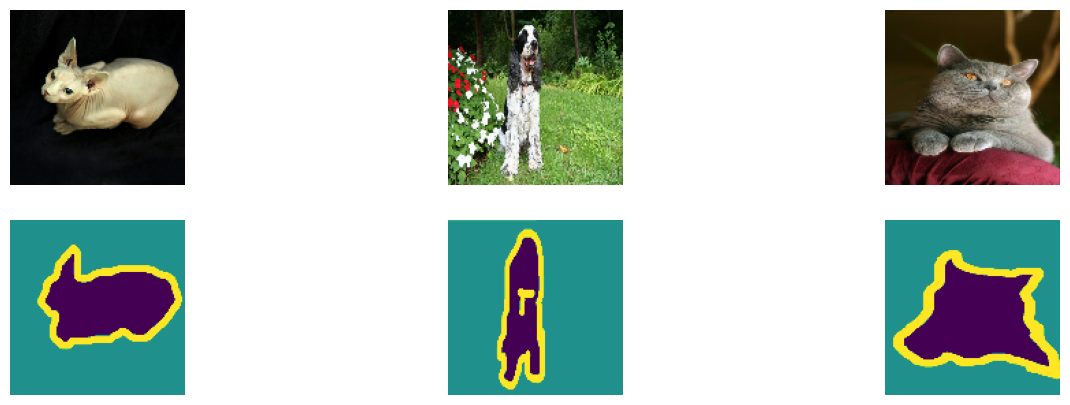

In [ ]:
# b) Create the segmentation mask
# Show some images from dataset and their segmented version

**Part 2- Annotation**

In [ ]:
# Install mrcnn

In [ ]:
# Get data from here https://github.com/experiencor/raccoon_dataset

Cloning into 'raccoon_dataset'...
remote: Enumerating objects: 646, done.
remote: Counting objects: 100% (646/646), done.
remote: Compressing objects: 100% (232/232), done.
remote: Total 646 (delta 413), reused 643 (delta 412), pack-reused 0 (from 0)
Receiving objects: 100% (646/646), 48.00 MiB | 22.96 MiB/s, done.
Resolving deltas: 100% (413/413), done.


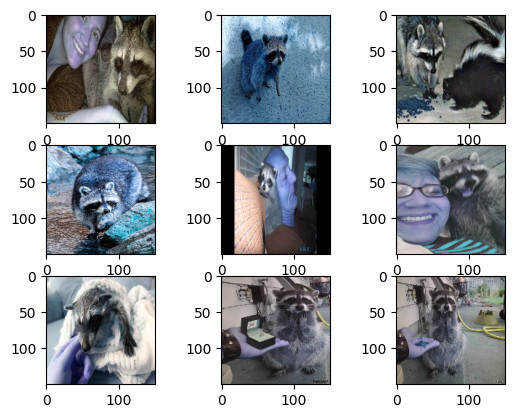

In [ ]:
# Look into data
# Plot some samples here

In [ ]:
from os import listdir
from xml.etree import ElementTree
from numpy import zeros
from numpy import asarray
from mrcnn.utils import Dataset

# class that defines and loads the raccoon dataset
class RaccoonDataset(Dataset):
	# load the dataset definitions
	def load_dataset(self, dataset_dir, is_train=True):
		# define one class
		self.add_class("raccoon_dataset", 1, "raccoon")
		# define data locations
		images_dir = dataset_dir + '/images/'
		annotations_dir = dataset_dir + '/annotations/raccoon-'
		# find all images
		for filename in listdir(images_dir):
			# extract image id
			image_id = filename[8:-4]
			# skip bad images
			if image_id in ['00090']:
				continue
			# skip all images after 150 if we are building the train set
			if is_train and int(image_id) >= 150:
				continue
			# skip all images before 150 if we are building the test/val set
			if not is_train and int(image_id) < 150:
				continue
			img_path = images_dir + filename
			ann_path = annotations_dir + image_id + '.xml'
			# add to dataset
			self.add_image('dataset', image_id=image_id, path=img_path, annotation=ann_path)

	# extract bounding boxes from an annotation file
	def extract_boxes(self, filename):
		# load and parse the file
		tree = ElementTree.parse(filename)
		# get the root of the document
		root = tree.getroot()
		# extract each bounding box
		boxes = list()
		for box in root.findall('.//bndbox'):
			xmin = int(box.find('xmin').text)
			ymin = int(box.find('ymin').text)
			xmax = int(box.find('xmax').text)
			ymax = int(box.find('ymax').text)
			coors = [xmin, ymin, xmax, ymax]
			boxes.append(coors)
		# extract image dimensions
		width = int(root.find('.//size/width').text)
		height = int(root.find('.//size/height').text)
		return boxes, width, height

	# load the masks for an image
	def load_mask(self, image_id):
		# get details of image
		info = self.image_info[image_id]
		# define box file location
		path = info['annotation']
		# load XML
		#path = '/content/raccoon_dataset/annotations/raccoon-'+image_id   #Added by me
		boxes, w, h = self.extract_boxes(path)
		# create one array for all masks, each on a different channel
		masks = zeros([h, w, len(boxes)], dtype='uint8')
		# create masks
		class_ids = list()
		for i in range(len(boxes)):
			box = boxes[i]
			row_s, row_e = box[1], box[3]
			col_s, col_e = box[0], box[2]
			masks[row_s:row_e, col_s:col_e, i] = 1
			class_ids.append(self.class_names.index('raccoon'))
		return masks, asarray(class_ids, dtype='int32')

	# load an image reference
	def image_reference(self, image_id):
		info = self.image_info[image_id]
		return info['path']

# train set
train_set = RaccoonDataset()
train_set.load_dataset('raccoon_dataset', is_train=True)
train_set.prepare()
print('Train: %d' % len(train_set.image_ids))

# test/val set
test_set = RaccoonDataset()
test_set.load_dataset('raccoon_dataset', is_train=False)
test_set.prepare()
print('Test: %d' % len(test_set.image_ids))

Train: 149
Test: 51


(371, 660, 3)
(371, 660, 1)


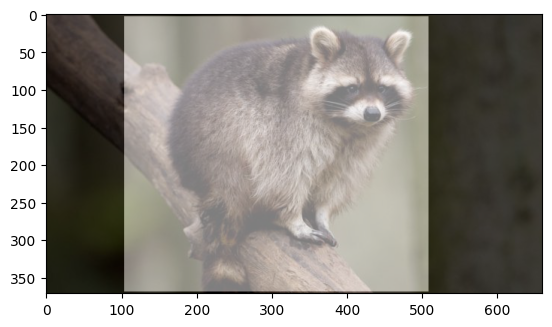

In [ ]:
# load an image
# Use the function above to create the image and its mask

**Part 3- YOLO**



You can see how YOLO has been improved in the last few versions on COCO: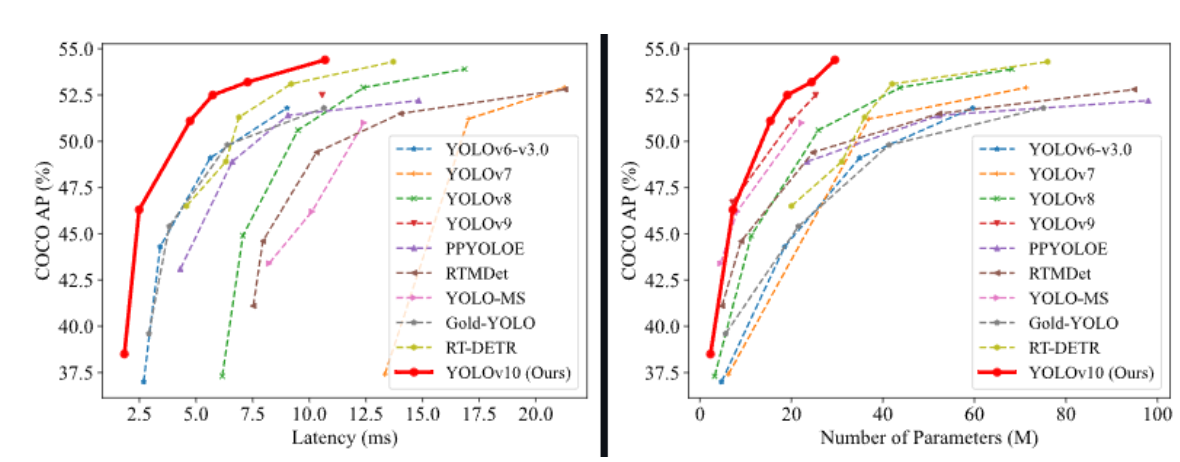

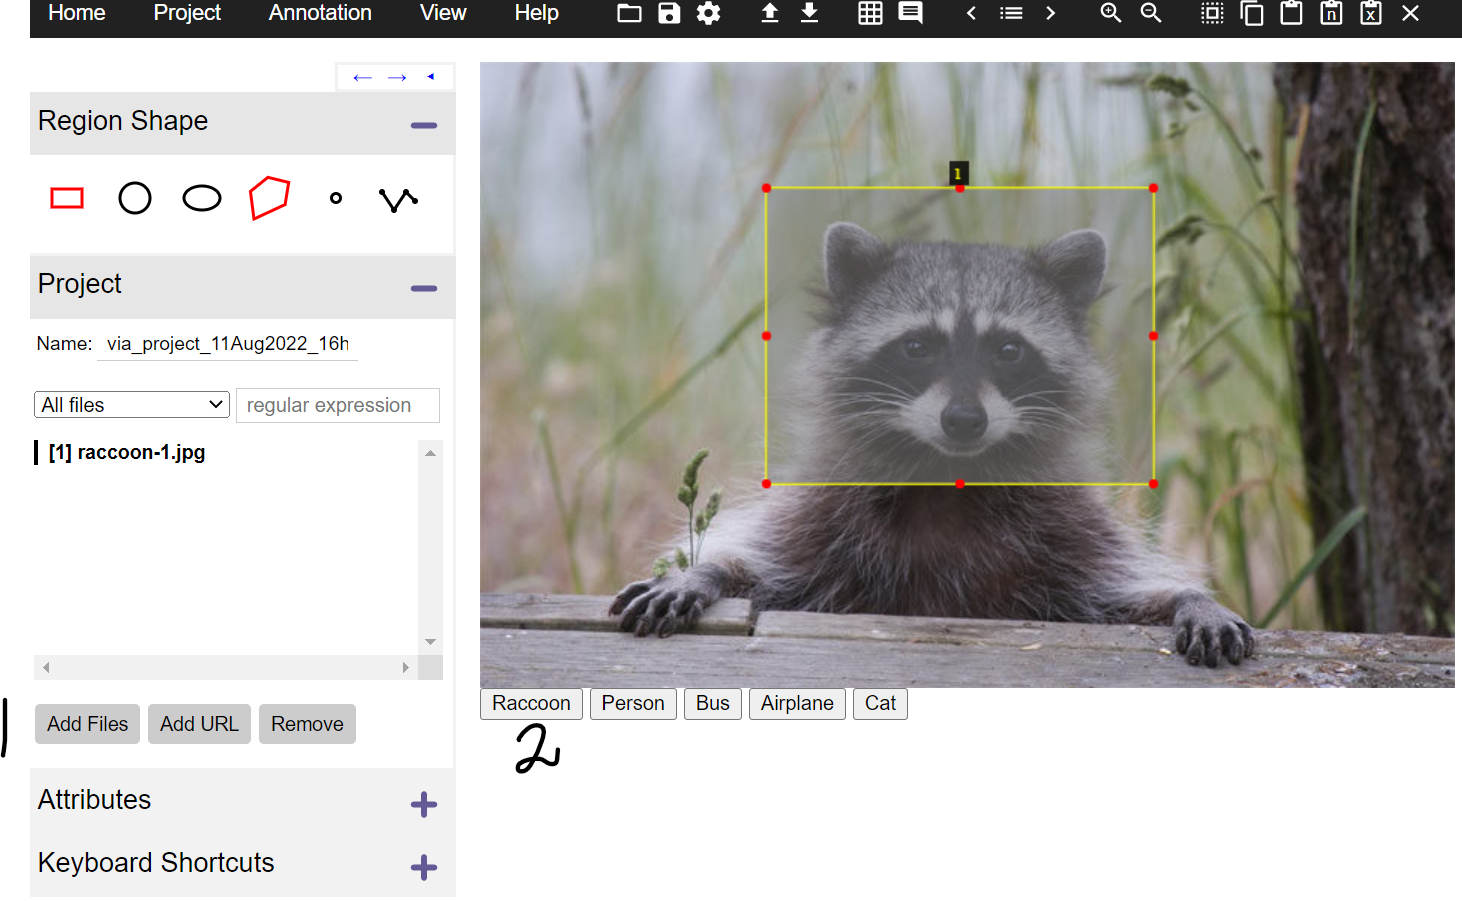

In [ ]:
# a- Create annotation
# You can upload the file using ![title](filename.jpeg)
# import image module

In [ ]:
#Some information about your GPU
!nvidia-smi


Tue Sep 15 00:44:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P0             29W /   70W |     111MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
#b- Download required tools
import os
HOME = os.getcwd()

In [ ]:
#You can download YOLO 11 model here
!wget https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11n.pt -O yolo11n.pt

--2026-09-15 00:44:13--  https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11n.pt
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/521807533/34b70ade-b6eb-4179-a60f-d6494307226b?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-09-15T01%3A42%3A10Z&rscd=attachment%3B+filename%3Dyolo11n.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-09-15T00%3A41%3A44Z&ske=2026-09-15T01%3A42%3A10Z&sks=b&skv=2018-11-09&sig=yaDACxPxi%2FJiBT6aBOr6kP4lhIENbsyw1899Uzdxlnc%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4OTQzMzM1MywibmJmIjoxNzg5NDMzMDUzLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNvcmU

In [ ]:
#c- Test the model out of box
# Update the ultralytics package to the absolute latest version
!pip install -U ultralytics

from ultralytics import YOLO
# Load the locally downloaded model
model = YOLO()   # Insert model here
model.predict() #Make a prediction on this image: https://ultralytics.com/images/bus.jpg

/content


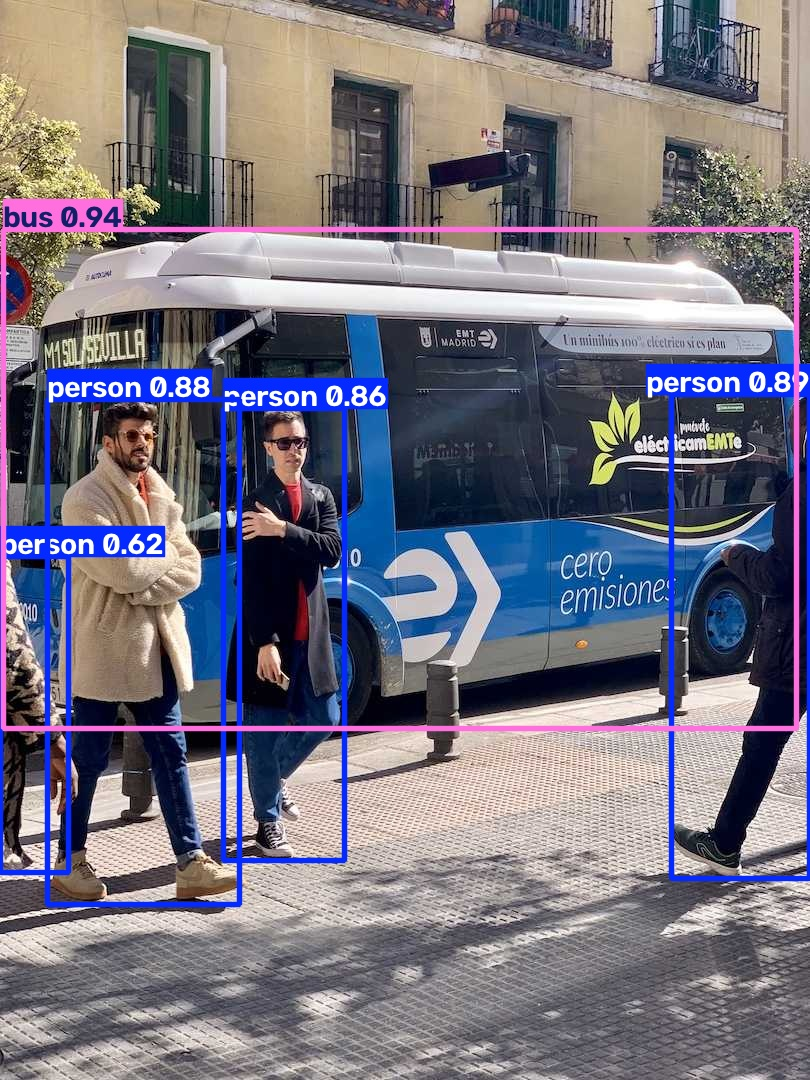

In [ ]:
%cd {HOME}
from IPython.display import Image
# The predicted model is now saved under predict folder on your Google Drive
# Let's see it
Image(filename= ........ ) # Modify this code

In [ ]:
%cd {HOME}

#d- Apply model here
!yolo task=detect .... data=african-wildlife.yaml    #Modify this code

In [ ]:
#d- Fine-tune the model
# Show the learning curve and confusion matrix
Image(filename= )# Modify this code for confusion matrix- Hint: You can find it in runs/detect/train

In [ ]:
Image(filename=)# Modify this code for learning curves- Hint: You can find it in runs/detect/train

In [ ]:
#e) Explain what you see in the learning curves and confusion matrix.